# VAR Parameter Estimation

The Vector Auto Regressive Process is a generalization of the single variable Autoregressive (AR) process to multiple variables. The $\text{VAR}(n)$ </br> 
is defined by,

$
\begin{align}
X_t = \mathcal{M} + \Phi_1 X_{t-1} \Phi_2 X_{t-2} + \cdots + \Phi_n X_{t-n} + \mathcal{E}_t
\end{align}
\tag{1}
$

where $t = 1, 2, 3, \ldots, T$, $X_t$ is column vector of length $m$ representing the time series, $\mathcal{M}$ is a $m$ element constant offset column vector, $\Phi_t$ are $m \times m$ matrices denoting constant coefficients and $\mathcal{E}_t$ an a random column normal vector with zero mean and covariance matrix $\Omega$,

$
\begin{align}
\mathcal{E}_t \sim \text{Normal}(0, \Omega)
\end{align}
\tag{2}
$

It follows that,

$
\begin{align}
\text{Cov}(\mathcal{E}_t, \mathcal{E}_s) = \Omega 
\end{align}
\tag{3}
$

Given a multivariate time series $X_t$ the following parameters are estimated: $\mathcal{M}$, $\Phi_n$ and $\Omega$. Here simulations are performed for specified values of the parameters and estimation methods the take the simulated $X_t$ as input are tested by comparing the result to the values specified .

## Imports

In [59]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot
import numpy

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import var, stats
from lib.plots import stack, fpoints, fcurve, PlotType

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [60]:
def comparison_plot(xt, title, ylim=(-2.5, 2.5), xlim=(0, 1000)):
    ylabels = [f"$S_{i+1}(t)$" for i in range(len(xt))]
    stack(xt, ylim=ylim, xlim=xlim, title=title, ylabels=ylabels, xlabel=r"$t$", figsize=(10, 6), title_offset=0.2, lw=1)

## $\text{VAR}(1)$ Simulations

### Uncoupled $\text{AR}(1)$

In [61]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.0],
                      [0.0, 0.25]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])

npts=5000
nlag=1
var.compute_is_stationary(phi)

True

In [62]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

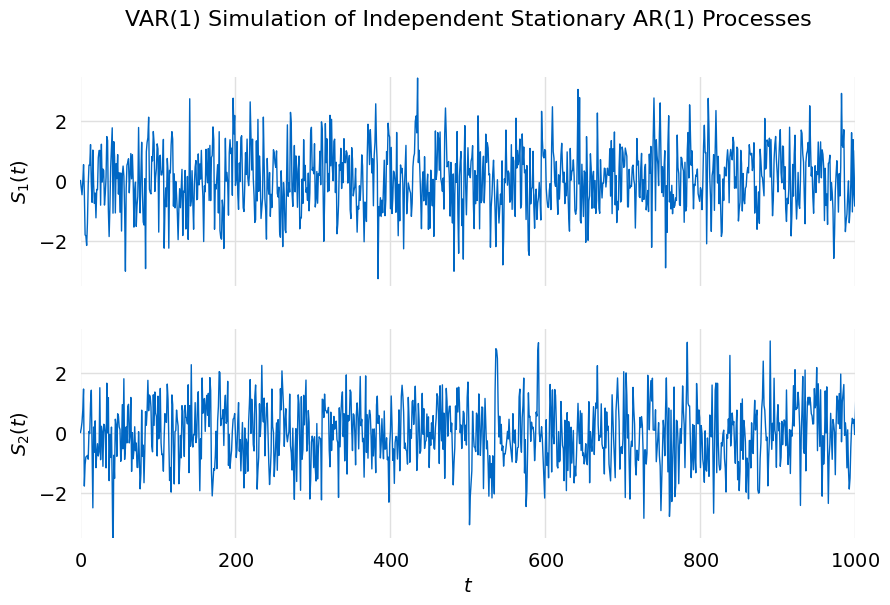

In [63]:
title = f"VAR(1) Simulation of Independent Stationary AR(1) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [64]:
result, result_model = var.compute_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.1657,0.1683,1.180,0.1666
1,0.04115*,0.04898*,1.042*,0.04390*
2,0.04214,0.05518,1.043,0.04671
3,0.04340,0.06166,1.044,0.04980
4,0.04298,0.06646,1.044,0.05121


In [65]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "ded99222-8fe1-4189-aebf-c3421aee1f6c",
   "_VAROrderTestReport__order": {
      "test_id": "ded99222-8fe1-4189-aebf-c3421aee1f6c",
      "label": "$\\tau_{min}$",
      "value": 1
   },
   "_VAROrderTestReport__aic": {
      "_LagOrderTestResult__test_id": "ded99222-8fe1-4189-aebf-c3421aee1f6c",
      "_LagOrderTestResult__order": {
         "test_id": "ded99222-8fe1-4189-aebf-c3421aee1f6c",
         "label": "$\\tau_{AIC}$",
         "value": 1
      },
      "_LagOrderTestResult__error_metric": "AIC",
      "_LagOrderTestResult__value": {
         "test_id": "ded99222-8fe1-4189-aebf-c3421aee1f6c",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.04115397697415644
      }
   },
   "_VAROrderTestReport__bic": {
      "_LagOrderTestResult__test_id": "ded99222-8fe1-4189-aebf-c3421aee1f6c",
      "_LagOrderTestResult__order": {
         "test_id": "ded99222-8fe1-4189-aebf-c3421aee1f6c",
         "label": "$\\tau_{BIC}$",
         "value":

In [66]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 24, Nov, 2023
Time:                     14:40:47
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  0.0479169
Nobs:                     4999.00    HQIC:                 0.0428365
Log likelihood:          -14280.8    FPE:                    1.04091
AIC:                    0.0400950    Det(Omega_mle):         1.03966
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.000991         0.014269           -0.069           0.945
L1.y1         0.226862         0.013774           16.470           0.000
L1.y2        -0.036845         0.013627           -2.704           0.007

Results for equation 

In [67]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": -0.0009908919293306236,
         "err": 0.01426871577152061,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "0b739135-e1d2-4cad-bca9-aab0785b332b",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.007109308389651875,
         "err": 0.014299578646277117,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 2,
         "est_id": "0b739135-e1d2-4cad-bca9-aab0785b332b",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 1,
   "_VAREst__params": [
      {
         "est": 0.22686199910517096,
         "err": 0.013774221006851706,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order": 

### Coupled $\text{AR}(1)$

In [68]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.05],
                      [0.5, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=1
var.compute_is_stationary(phi)

True

In [69]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

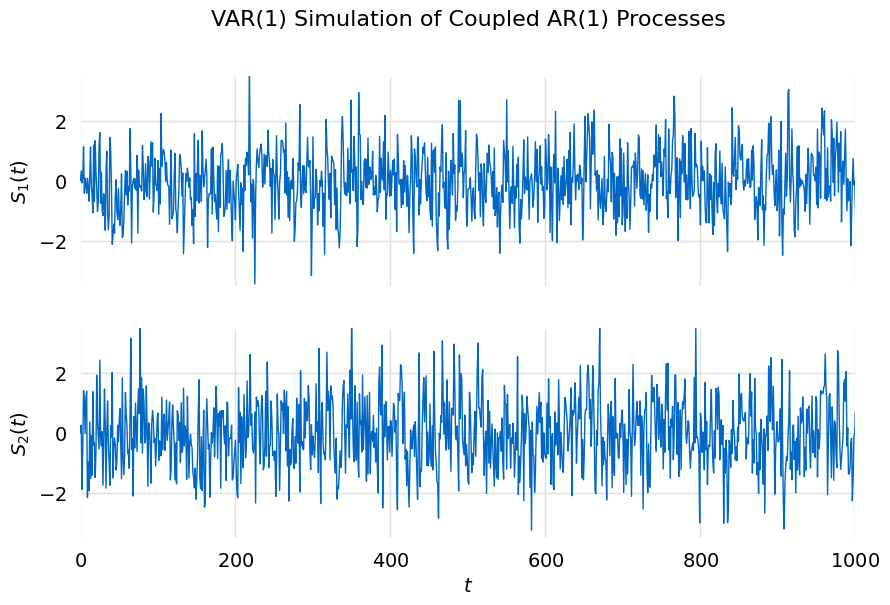

In [70]:
title = f"VAR(1) Simulation of Coupled AR(1) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [71]:
result, result_model = var.compute_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.3291,0.3317,1.390,0.3300
1,0.001666*,0.009492*,1.002*,0.004409*
2,0.002961,0.01600,1.003,0.007532
3,0.004096,0.02236,1.004,0.01050
4,0.005132,0.02861,1.005,0.01336


In [72]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "e77eccde-7409-42fb-a09b-367d060bbdbf",
   "_VAROrderTestReport__order": {
      "test_id": "e77eccde-7409-42fb-a09b-367d060bbdbf",
      "label": "$\\tau_{min}$",
      "value": 1
   },
   "_VAROrderTestReport__aic": {
      "_LagOrderTestResult__test_id": "e77eccde-7409-42fb-a09b-367d060bbdbf",
      "_LagOrderTestResult__order": {
         "test_id": "e77eccde-7409-42fb-a09b-367d060bbdbf",
         "label": "$\\tau_{AIC}$",
         "value": 1
      },
      "_LagOrderTestResult__error_metric": "AIC",
      "_LagOrderTestResult__value": {
         "test_id": "e77eccde-7409-42fb-a09b-367d060bbdbf",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.0016663362442302957
      }
   },
   "_VAROrderTestReport__bic": {
      "_LagOrderTestResult__test_id": "e77eccde-7409-42fb-a09b-367d060bbdbf",
      "_LagOrderTestResult__order": {
         "test_id": "e77eccde-7409-42fb-a09b-367d060bbdbf",
         "label": "$\\tau_{BIC}$",
         "value

In [73]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 24, Nov, 2023
Time:                     14:40:47
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                 0.00921761
Nobs:                     4999.00    HQIC:                0.00413716
Log likelihood:          -14184.0    FPE:                    1.00140
AIC:                   0.00139566    Det(Omega_mle):         1.00020
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.029048         0.014098            2.060           0.039
L1.y1         0.241563         0.013782           17.528           0.000
L1.y2         0.058736         0.012316            4.769           0.000

Results for equation 

In [74]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": 0.029047980621259982,
         "err": 0.014098109778030223,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "43ff3379-5cbf-4f44-ade3-8521d25c5c41",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.012875927941750513,
         "err": 0.014226698161480512,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 2,
         "est_id": "43ff3379-5cbf-4f44-ade3-8521d25c5c41",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 1,
   "_VAREst__params": [
      {
         "est": 0.2415630344651722,
         "err": 0.013781868733224619,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,

### Coupled $\text{AR}(1)$ With Non Unit Normal Noise

In [75]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.05],
                      [0.5, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[2.0, 0.2],
                      [0.2, 2.0]])
npts=5000
nlag=1
var.compute_is_stationary(phi)

True

In [76]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

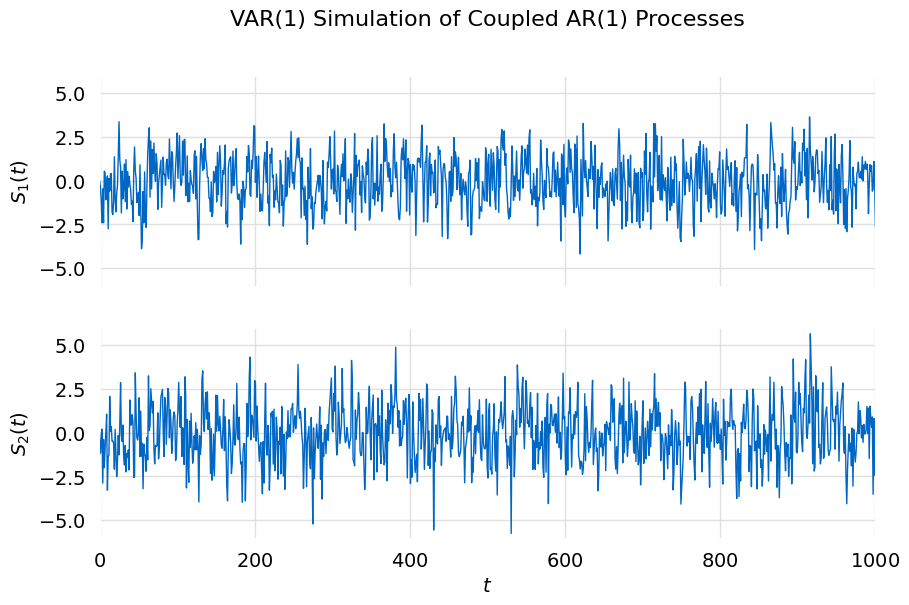

In [77]:
title = f"VAR(1) Simulation of Coupled AR(1) Processes"
comparison_plot(xt, title, ylim=(-6.0, 6.0))

In [78]:
result, result_model = var.compute_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,1.714,1.717,5.552,1.715
1,1.374*,1.382*,3.950*,1.376*
2,1.375,1.388,3.956,1.380
3,1.376,1.395,3.961,1.383
4,1.377,1.400,3.962,1.385


In [79]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "9b86bb9f-a6ee-4523-8926-8f35b36732b5",
   "_VAROrderTestReport__order": {
      "test_id": "9b86bb9f-a6ee-4523-8926-8f35b36732b5",
      "label": "$\\tau_{min}$",
      "value": 1
   },
   "_VAROrderTestReport__aic": {
      "_LagOrderTestResult__test_id": "9b86bb9f-a6ee-4523-8926-8f35b36732b5",
      "_LagOrderTestResult__order": {
         "test_id": "9b86bb9f-a6ee-4523-8926-8f35b36732b5",
         "label": "$\\tau_{AIC}$",
         "value": 1
      },
      "_LagOrderTestResult__error_metric": "AIC",
      "_LagOrderTestResult__value": {
         "test_id": "9b86bb9f-a6ee-4523-8926-8f35b36732b5",
         "label": "$\\varepsilon_{AIC}$",
         "value": 1.3736980659264393
      }
   },
   "_VAROrderTestReport__bic": {
      "_LagOrderTestResult__test_id": "9b86bb9f-a6ee-4523-8926-8f35b36732b5",
      "_LagOrderTestResult__order": {
         "test_id": "9b86bb9f-a6ee-4523-8926-8f35b36732b5",
         "label": "$\\tau_{BIC}$",
         "value": 

In [80]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 24, Nov, 2023
Time:                     14:40:48
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    1.38110
Nobs:                     4999.00    HQIC:                   1.37602
Log likelihood:          -17613.1    FPE:                    3.94829
AIC:                      1.37328    Det(Omega_mle):         3.94355
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.005985         0.019890           -0.301           0.763
L1.y1         0.261031         0.013923           18.748           0.000
L1.y2         0.057618         0.012377            4.655           0.000

Results for equation 

In [81]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": -0.005985143621279432,
         "err": 0.019889544182862342,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "0a949b11-47ee-4981-b2b5-83d9c36e0256",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.012844337863579247,
         "err": 0.020070555564841698,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 2,
         "est_id": "0a949b11-47ee-4981-b2b5-83d9c36e0256",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 1,
   "_VAREst__params": [
      {
         "est": 0.2610310830634447,
         "err": 0.01392289801577931,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order": 1

## $\text{VAR}(2)$ Simulations
### Uncoupled $\text{AR}(2)$

In [82]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.0],
                      [0.0, 0.25]]),
        numpy.matrix([[0.5, 0.0],
                      [0.0, 0.5]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=2
var.compute_is_stationary(phi)

True

In [83]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

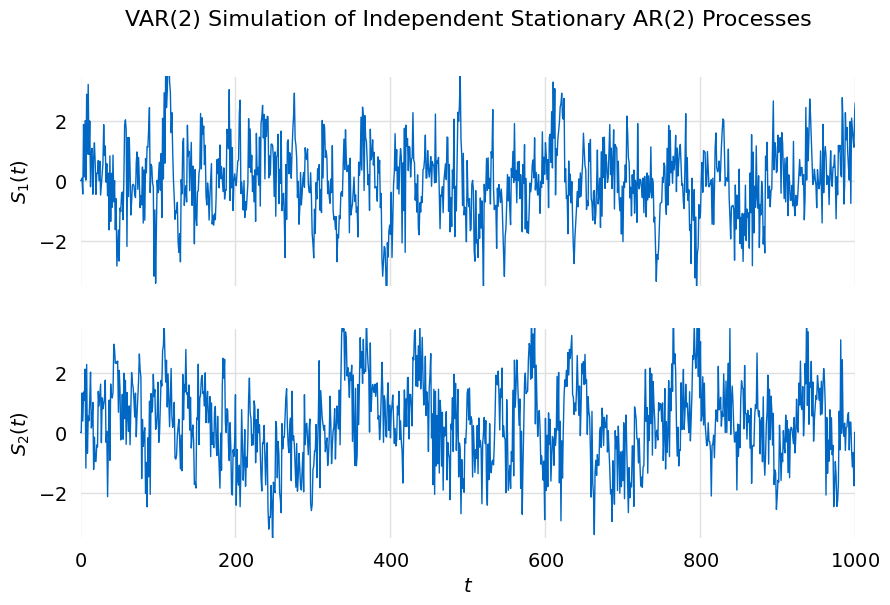

In [84]:
title = f"VAR(2) Simulation of Independent Stationary AR(2) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [85]:
result, result_model = var.compute_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,1.232,1.235,3.429,1.233
1,0.5613,0.5691,1.753,0.5640
2,0.007177*,0.02022*,1.007*,0.01175*
3,0.008385,0.02665,1.008,0.01479
4,0.008152,0.03163,1.008,0.01638


In [86]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "d5ee41d8-34b2-4b32-8b9c-7a0e578a3d6f",
   "_VAROrderTestReport__order": {
      "test_id": "d5ee41d8-34b2-4b32-8b9c-7a0e578a3d6f",
      "label": "$\\tau_{min}$",
      "value": 2
   },
   "_VAROrderTestReport__aic": {
      "_LagOrderTestResult__test_id": "d5ee41d8-34b2-4b32-8b9c-7a0e578a3d6f",
      "_LagOrderTestResult__order": {
         "test_id": "d5ee41d8-34b2-4b32-8b9c-7a0e578a3d6f",
         "label": "$\\tau_{AIC}$",
         "value": 2
      },
      "_LagOrderTestResult__error_metric": "AIC",
      "_LagOrderTestResult__value": {
         "test_id": "d5ee41d8-34b2-4b32-8b9c-7a0e578a3d6f",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.007177273013971982
      }
   },
   "_VAROrderTestReport__bic": {
      "_LagOrderTestResult__test_id": "d5ee41d8-34b2-4b32-8b9c-7a0e578a3d6f",
      "_LagOrderTestResult__order": {
         "test_id": "d5ee41d8-34b2-4b32-8b9c-7a0e578a3d6f",
         "label": "$\\tau_{BIC}$",
         "value"

In [87]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 24, Nov, 2023
Time:                     14:40:48
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  0.0198080
Nobs:                     4998.00    HQIC:                 0.0113392
Log likelihood:          -14190.6    FPE:                    1.00679
AIC:                   0.00676922    Det(Omega_mle):         1.00478
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.004832         0.014293           -0.338           0.735
L1.y1         0.253707         0.012288           20.646           0.000
L1.y2         0.019386         0.012545            1.545           0.122
L2.y1         0.496262

In [88]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": -0.004832376091451663,
         "err": 0.014292547931789133,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "c04e780c-6e95-4432-89d7-15d707efc017",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.013021784087735903,
         "err": 0.014069113524637382,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 2,
         "est_id": "c04e780c-6e95-4432-89d7-15d707efc017",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 2,
   "_VAREst__params": [
      {
         "est": 0.25370705585546166,
         "err": 0.012288181122986436,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order": 

### Coupled $\text{AR}(2)$

In [89]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.15],
                      [0.1, 0.1]]),
        numpy.matrix([[0.25, 0.3],
                      [0.2, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=2
var.compute_is_stationary(phi)

True

In [90]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

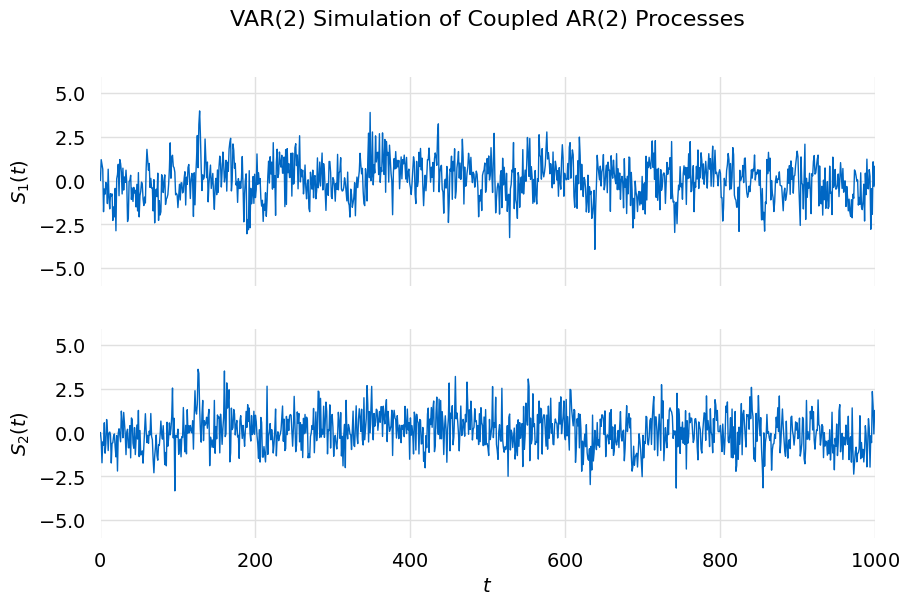

In [91]:
title = f"VAR(2) Simulation of Coupled AR(2) Processes"
comparison_plot(xt, title, ylim=(-6.0, 6.0))

In [92]:
result, result_model = var.compute_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.4962,0.4988,1.642,0.4971
1,0.2823,0.2902,1.326,0.2851
2,0.02789*,0.04094*,1.028*,0.03247*
3,0.02897,0.04723,1.029,0.03537
4,0.02837,0.05185,1.029,0.03660


In [93]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "fa57b7a8-a0eb-45a0-b3ef-e5841587d798",
   "_VAROrderTestReport__order": {
      "test_id": "fa57b7a8-a0eb-45a0-b3ef-e5841587d798",
      "label": "$\\tau_{min}$",
      "value": 2
   },
   "_VAROrderTestReport__aic": {
      "_LagOrderTestResult__test_id": "fa57b7a8-a0eb-45a0-b3ef-e5841587d798",
      "_LagOrderTestResult__order": {
         "test_id": "fa57b7a8-a0eb-45a0-b3ef-e5841587d798",
         "label": "$\\tau_{AIC}$",
         "value": 2
      },
      "_LagOrderTestResult__error_metric": "AIC",
      "_LagOrderTestResult__value": {
         "test_id": "fa57b7a8-a0eb-45a0-b3ef-e5841587d798",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.027894893528774778
      }
   },
   "_VAROrderTestReport__bic": {
      "_LagOrderTestResult__test_id": "fa57b7a8-a0eb-45a0-b3ef-e5841587d798",
      "_LagOrderTestResult__order": {
         "test_id": "fa57b7a8-a0eb-45a0-b3ef-e5841587d798",
         "label": "$\\tau_{BIC}$",
         "value"

In [94]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 24, Nov, 2023
Time:                     14:40:49
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  0.0412274
Nobs:                     4998.00    HQIC:                 0.0327585
Log likelihood:          -14244.2    FPE:                    1.02859
AIC:                    0.0281886    Det(Omega_mle):         1.02653
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.003890         0.014266            0.273           0.785
L1.y1         0.137197         0.012961           10.585           0.000
L1.y2         0.145303         0.013702           10.605           0.000
L2.y1         0.250630

In [95]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": 0.003889558935412456,
         "err": 0.014266414282643348,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "8b3f03f5-c804-4a18-9f79-eee9cd31b433",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.014577764029638323,
         "err": 0.014234324376386862,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 2,
         "est_id": "8b3f03f5-c804-4a18-9f79-eee9cd31b433",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 2,
   "_VAREst__params": [
      {
         "est": 0.13719656561795351,
         "err": 0.01296139621632986,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,

## $\text{VAR}(3)$ Simulations
### Uncoupled $\text{AR}(3)$

In [96]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.0, 0.0],
                      [0.0, 0.15, 0.0],
                      [0.0, 0.0, 0.05]]),
        numpy.matrix([[0.05, 0.0, 0.0],
                      [0.0, 0.1, 0.0],
                      [0.0, 0.0, 0.05]]),
        numpy.matrix([[0.15, 0.0, 0.0],
                      [0.0, 0.15, 0.0],
                      [0.0, 0.0, 0.05]])])
mu = numpy.array([0.0, 0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0, 0.0],
                      [0.0, 1.0, 0.0],
                      [0.0, 0.0, 1.0]])
var.compute_is_stationary(phi)
npts=5000
nlag=3

In [97]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

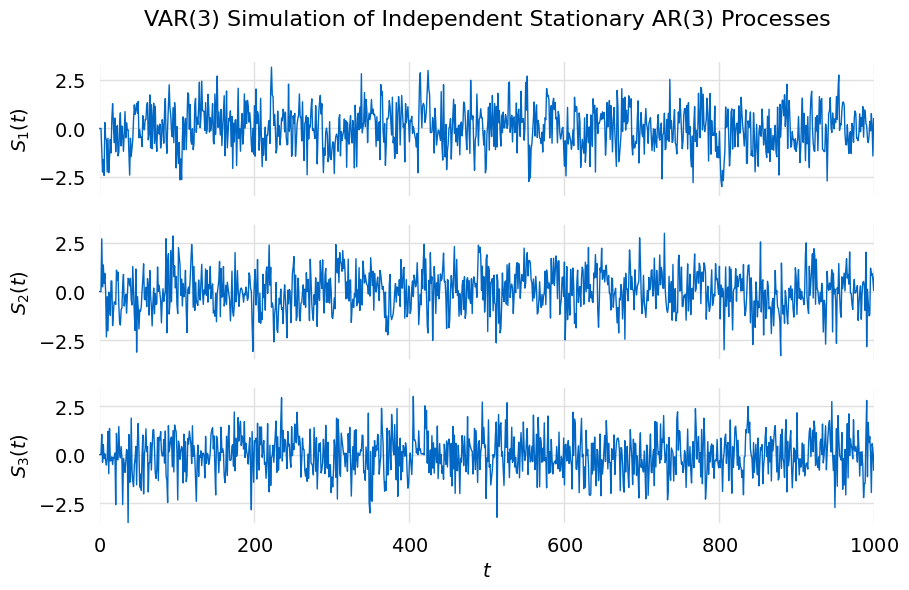

In [98]:
title = f"VAR(3) Simulation of Independent Stationary AR(3) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [99]:
result, result_model = var.compute_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.1931,0.1970,1.213,0.1945
1,0.1104,0.1260,1.117,0.1158
2,0.08262,0.1100,1.086,0.09222
3,0.03703,0.07616*,1.038,0.05075*
4,0.03684*,0.08771,1.038*,0.05467


In [100]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "d0b96367-fb4e-44eb-bc0e-4f9438d7039c",
   "_VAROrderTestReport__order": {
      "test_id": "d0b96367-fb4e-44eb-bc0e-4f9438d7039c",
      "label": "$\\tau_{min}$",
      "value": 3
   },
   "_VAROrderTestReport__aic": {
      "_LagOrderTestResult__test_id": "d0b96367-fb4e-44eb-bc0e-4f9438d7039c",
      "_LagOrderTestResult__order": {
         "test_id": "d0b96367-fb4e-44eb-bc0e-4f9438d7039c",
         "label": "$\\tau_{AIC}$",
         "value": 4
      },
      "_LagOrderTestResult__error_metric": "AIC",
      "_LagOrderTestResult__value": {
         "test_id": "d0b96367-fb4e-44eb-bc0e-4f9438d7039c",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.03683698770041098
      }
   },
   "_VAROrderTestReport__bic": {
      "_LagOrderTestResult__test_id": "d0b96367-fb4e-44eb-bc0e-4f9438d7039c",
      "_LagOrderTestResult__order": {
         "test_id": "d0b96367-fb4e-44eb-bc0e-4f9438d7039c",
         "label": "$\\tau_{BIC}$",
         "value":

In [101]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 24, Nov, 2023
Time:                     14:40:50
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                  0.0775434
Nobs:                     4997.00    HQIC:                 0.0521328
Log likelihood:          -21337.3    FPE:                    1.03917
AIC:                    0.0384204    Det(Omega_mle):         1.03295
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.002540         0.014341            0.177           0.859
L1.y1         0.159855         0.014005           11.414           0.000
L1.y2        -0.015988         0.014169           -1.128           0.259
L1.y3        -0.004950

In [102]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": 0.0025400820912363747,
         "err": 0.014341219400899635,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "a956b468-959f-4d65-9c21-886d297df322",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.016300887316809173,
         "err": 0.014170940176520291,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 2,
         "est_id": "a956b468-959f-4d65-9c21-886d297df322",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.00782361371221704,
         "err": 0.014202761216141654,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 3,
         "est_id": "a956b468-959f-4d65-9c21-886d297df3

### Coupled $\text{AR}(3)$

In [103]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.1, 0.2],
                      [0.0, 0.15, 0.1],
                      [0.05, 0.025, 0.05]]),
        numpy.matrix([[0.015, 0.01, 0.0],
                      [0.1, 0.1, 0.05],
                      [0.1, 0.05, 0.05]]),
        numpy.matrix([[0.15, 0.05, 0.1],
                      [0.0, 0.15, 0.025],
                      [0.025, 0.15, 0.05]])])
mu = numpy.array([0.0, 0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0, 0.0],
                      [0.0, 1.0, 0.0],
                      [0.0, 0.0, 1.0]])
npts=5000
nlag=3
var.compute_is_stationary(phi)


True

In [104]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

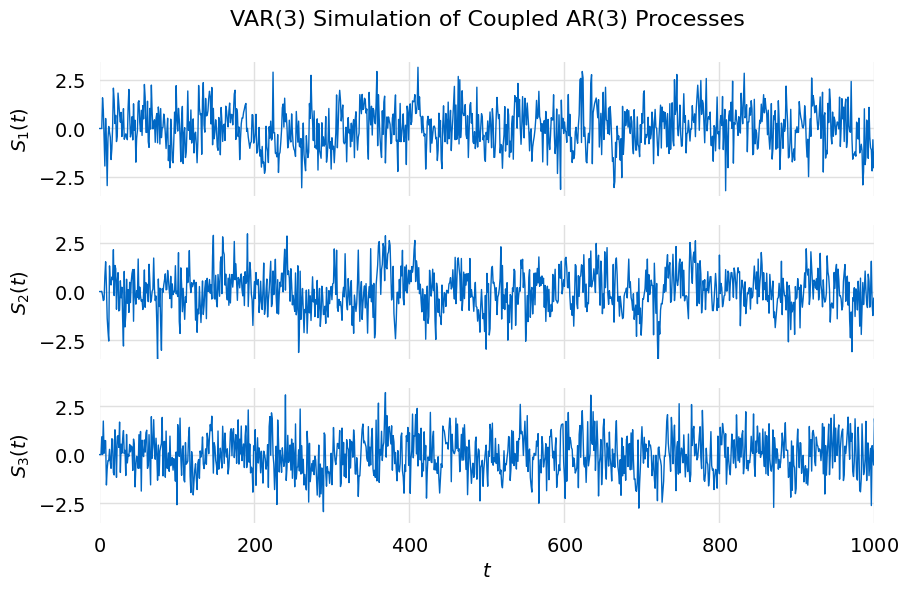

In [105]:
title = f"VAR(3) Simulation of Coupled AR(3) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [106]:
result, result_model = var.compute_order(xt, maxlags=5)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.3907,0.3947,1.478,0.3921
1,0.1749,0.1905,1.191,0.1803
2,0.09922,0.1266,1.104,0.1088
3,0.02216*,0.06129*,1.022*,0.03587*
4,0.02463,0.07550,1.025,0.04246
5,0.02654,0.08916,1.027,0.04849


In [107]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "a0ce893e-b94f-4ed1-9fed-b42a0e2f731d",
   "_VAROrderTestReport__order": {
      "test_id": "a0ce893e-b94f-4ed1-9fed-b42a0e2f731d",
      "label": "$\\tau_{min}$",
      "value": 3
   },
   "_VAROrderTestReport__aic": {
      "_LagOrderTestResult__test_id": "a0ce893e-b94f-4ed1-9fed-b42a0e2f731d",
      "_LagOrderTestResult__order": {
         "test_id": "a0ce893e-b94f-4ed1-9fed-b42a0e2f731d",
         "label": "$\\tau_{AIC}$",
         "value": 3
      },
      "_LagOrderTestResult__error_metric": "AIC",
      "_LagOrderTestResult__value": {
         "test_id": "a0ce893e-b94f-4ed1-9fed-b42a0e2f731d",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.022156228697989295
      }
   },
   "_VAROrderTestReport__bic": {
      "_LagOrderTestResult__test_id": "a0ce893e-b94f-4ed1-9fed-b42a0e2f731d",
      "_LagOrderTestResult__order": {
         "test_id": "a0ce893e-b94f-4ed1-9fed-b42a0e2f731d",
         "label": "$\\tau_{BIC}$",
         "value"

In [108]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 24, Nov, 2023
Time:                     14:40:50
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                  0.0606715
Nobs:                     4997.00    HQIC:                 0.0352609
Log likelihood:          -21295.1    FPE:                    1.02178
AIC:                    0.0215485    Det(Omega_mle):         1.01567
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.001916         0.014068           -0.136           0.892
L1.y1         0.158657         0.013913           11.404           0.000
L1.y2         0.098974         0.013781            7.182           0.000
L1.y3         0.176689

In [109]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": -0.001915663299234929,
         "err": 0.014067790790735066,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "4208b2df-e430-4456-8e2e-a4f5eca57701",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.0033470386790019416,
         "err": 0.014309936993067797,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 2,
         "est_id": "4208b2df-e430-4456-8e2e-a4f5eca57701",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.021047145052815415,
         "err": 0.014223066126653477,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 3,
         "est_id": "4208b2df-e430-4456-8e2e-a4f5eca57